In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN
from ChebyKANLayer import ChebyKANLayer

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.3, 1.5]

In [3]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 50, 10, 150)

100%|██████████| 1000/1000 [39:01<00:00,  2.34s/it]


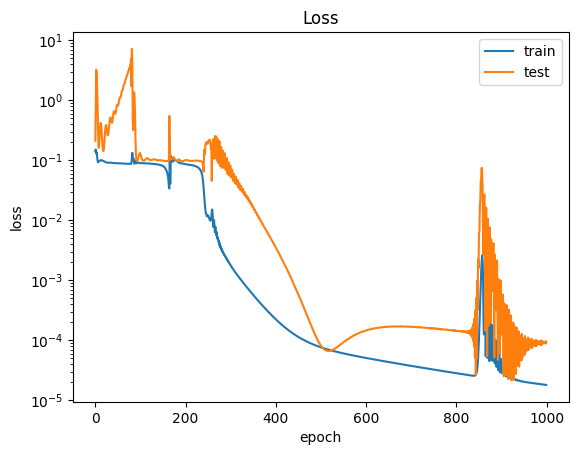

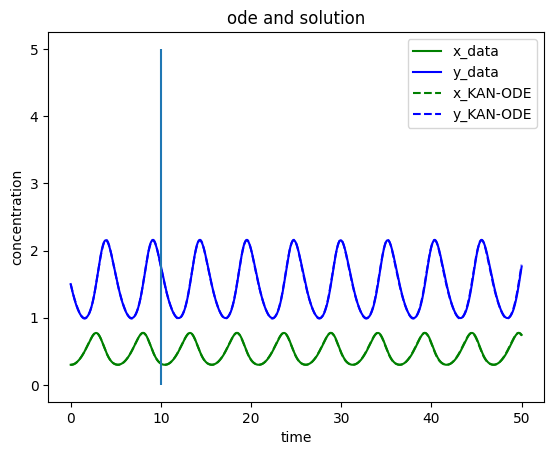

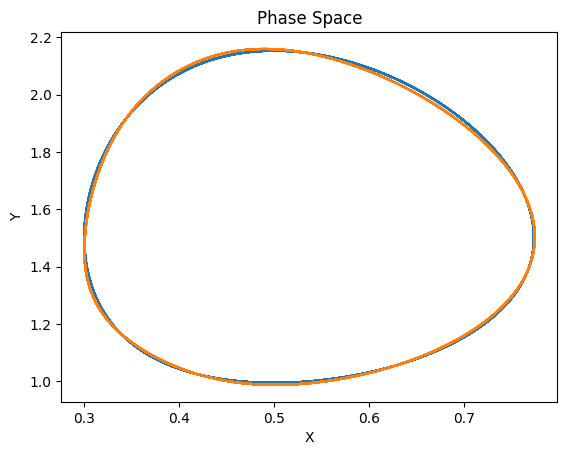

In [4]:
kanODE.train(1000)
_, solution = kanODE.test()
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

In [21]:
def vanDerPoll(X, t, epsilon):
    x = X[0]
    y = X[1]
    dxdt = y
    dydt = epsilon*(1-x*x)*y - x
    return [dxdt, dydt]
vdpX0 = [0, 1.5]
vdpParams = [0.2]

In [24]:
model2 = ChebyKAN([2, 10, 2], 4)
kanODE2 = KANODE(model, vanDerPoll, vdpX0, vdpParams, 50, 20, 150)

100%|██████████| 1000/1000 [1:32:07<00:00,  5.53s/it]


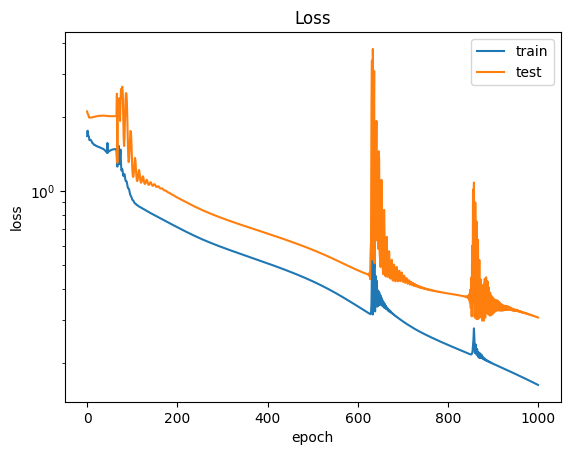

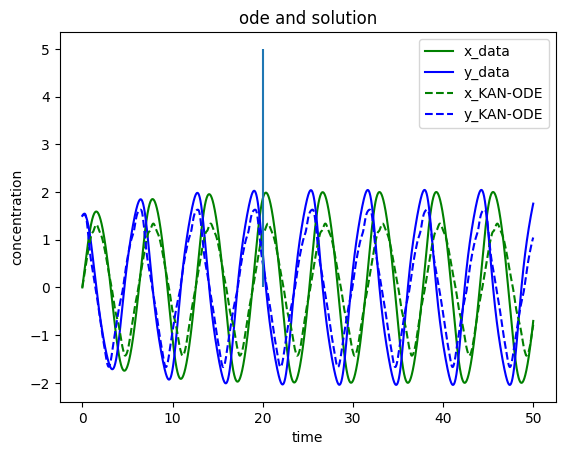

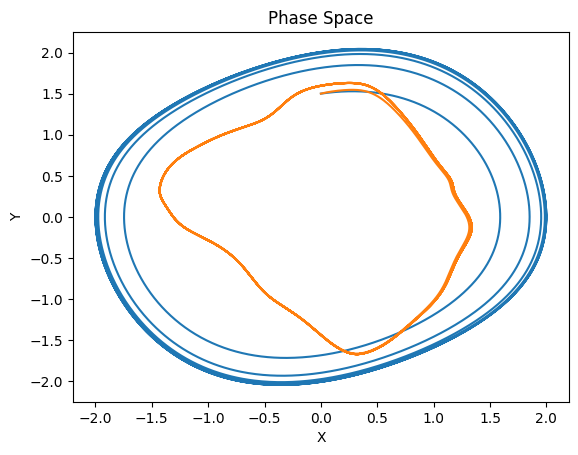

In [25]:
kanODE2.train(1000)
_, solution = kanODE2.test()
kanODE2.plotLoss("Loss")
kanODE2.plotODE("ode and solution", solution[:, 0, :])
kanODE2.plotPhaseSpace("Phase Space", solution[:, 0, :])

100%|██████████| 500/500 [49:28<00:00,  5.94s/it]


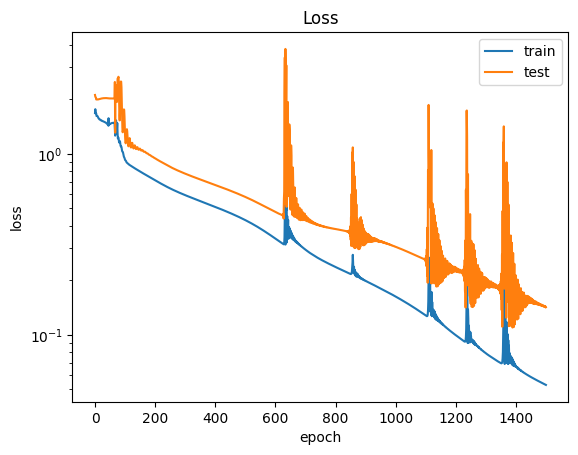

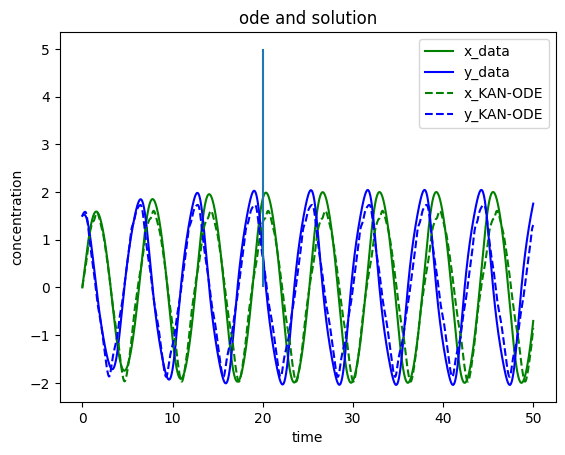

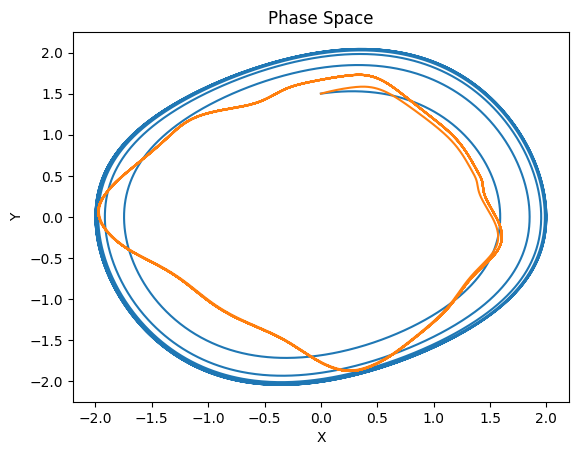

In [26]:
kanODE2.train(500)
_, solution = kanODE2.test()
kanODE2.plotLoss("Loss")
kanODE2.plotODE("ode and solution", solution[:, 0, :])
kanODE2.plotPhaseSpace("Phase Space", solution[:, 0, :])